# Week 8: Reinforcement Learning for Quantum Applications

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*Control, circuits, feedback, error correction, and adaptive sensing*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(8)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- translate a quantum protocol into states, observations, actions, rewards, and episodes;
- distinguish a simulator state $\rho_t$ from an experimentally available observation $O_t$;
- formulate state preparation and circuit synthesis as finite-horizon control;
- describe measurement backaction and belief-state feedback with density matrices;
- evaluate a quantum-error-correction policy using rare-event statistics;
- formulate adaptive quantum sensing as sequential experiment design;
- distinguish classical RL on quantum systems from quantum reinforcement learning.

The examples are deliberately small enough to inspect numerically. They illustrate interfaces and validation principles rather than claiming quantum advantage.

## 1. The quantum device is the environment

In most quantum-control applications, the policy is classical and the controlled system is quantum. A convenient physical state is a density matrix,

$$
\rho_t\succeq0,\qquad \operatorname{Tr}\rho_t=1.
$$

A control action $a_t$ induces a completely positive trace-preserving map,

$$
\rho_{t+1}=\mathcal E_{a_t}(\rho_t).
$$

If a measurement with Kraus operators $\{M_o\}$ produces outcome $o$, then

$$
p(o\mid\rho)=\operatorname{Tr}(M_o\rho M_o^\dagger),
$$

$$
\rho\mid o=\frac{M_o\rho M_o^\dagger}{p(o\mid\rho)}.
$$

The exact wavefunction or density matrix may be available in simulation, but a laboratory controller receives measurement outcomes, estimated observables, or a history of detector records. Quantum feedback is therefore usually a partially observed control problem.

| RL object | Quantum interpretation |
|---|---|
| physical state | $|\psi_t\rangle$ or $\rho_t$ |
| observation | measurement outcome, expectation value, syndrome history |
| action | pulse, gate, measurement basis, correction, circuit edit |
| transition | Schrodinger, Lindblad, or measurement-update dynamics |
| reward | fidelity, energy, sensitivity, logical error, control cost |

### Model-free does not mean physics-free

A model-free update does not differentiate through a known transition model. The environment must still implement physical dynamics, noise, measurement, timing, and constraints. A policy trained against an inaccurate simulator can exploit its artifacts.

The unit of evaluation is therefore not merely a neural-network score. It is a protocol tested under a specified Hamiltonian, noise model, observation process, action bandwidth, and shot budget.

## 2. A small numerical quantum toolkit

In [2]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H_GATE = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

KET0 = np.array([1, 0], dtype=complex)
KET1 = np.array([0, 1], dtype=complex)
KET00 = np.kron(KET0, KET0)
BELL_PHI_PLUS = (np.kron(KET0, KET0) + np.kron(KET1, KET1)) / np.sqrt(2)

def pure_density(state):
    state = np.asarray(state, dtype=complex)
    return np.outer(state, state.conj())

def pure_state_fidelity(state, target):
    return float(abs(np.vdot(target, state))**2)

def density_target_fidelity(rho, target):
    return float(np.real(np.vdot(target, rho @ target)))

def apply_unitary_density(rho, unitary):
    return unitary @ rho @ unitary.conj().T

rho0 = pure_density(KET0)
print("Trace:", np.trace(rho0))
print("Eigenvalues:", np.linalg.eigvalsh(rho0))
print("Fidelity with |0>:", density_target_fidelity(rho0, KET0))

Trace: (1+0j)
Eigenvalues: [0. 1.]
Fidelity with |0>: 1.0


## 3. State preparation, gate design, and reward design

For controlled Hamiltonian

$$
H(t)=H_0+\sum_k u_k(t)H_k,
$$

the state evolves as

$$
|\psi(T)\rangle=\mathcal T\exp\left[-i\int_0^T H(t)dt\right]|\psi(0)\rangle.
$$

A standard state-preparation objective is

$$
F_T=|\langle\psi_*|\psi(T)\rangle|^2.
$$

A practical reward may also penalize energy and bandwidth,

$$
R=F_T-\lambda\sum_t\|u_t\|^2
-\eta\sum_t\|u_t-u_{t-1}\|^2.
$$

Fidelity is useful in simulation but may be unavailable experimentally. Observable proxies, randomized benchmarking, sensitivity, or task-specific success probabilities may be required. A proxy reward must be validated against the physical objective it is intended to represent.

## Example 1: Bell-state preparation as circuit synthesis

Circuit design can be viewed as sequential program synthesis. The state is the current quantum state and remaining depth; the action appends a gate. The target is

$$
|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

The action set below contains single-qubit $H$ and $X$ gates, two CNOT orientations, and an identity action. Q-learning searches for a short circuit. This example uses exact statevectors and is therefore a simulator-side formulation, not an experimentally observable Markov state.

In [3]:
CNOT_01 = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
], dtype=complex)
CNOT_10 = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
], dtype=complex)

gate_names = ["H0", "H1", "X0", "X1", "CNOT01", "CNOT10", "I"]
gate_matrices = [
    np.kron(H_GATE, I2),
    np.kron(I2, H_GATE),
    np.kron(X, I2),
    np.kron(I2, X),
    CNOT_01,
    CNOT_10,
    np.eye(4, dtype=complex),
]

def canonical_state_key(state, decimals=7):
    state = np.asarray(state, dtype=complex)
    nonzero = np.flatnonzero(np.abs(state) > 1e-10)
    if len(nonzero):
        phase = state[nonzero[0]] / abs(state[nonzero[0]])
        state = state / phase
    values = np.concatenate([state.real, state.imag])
    return tuple(np.round(values, decimals))

class BellCircuitEnv:
    def __init__(self, max_depth=4):
        self.max_depth = max_depth

    def reset(self):
        self.state = KET00.copy()
        self.depth = 0
        return self.observation()

    def observation(self):
        return self.depth, canonical_state_key(self.state)

    def step(self, action):
        old_fidelity = pure_state_fidelity(self.state, BELL_PHI_PLUS)
        self.state = gate_matrices[action] @ self.state
        self.depth += 1
        fidelity = pure_state_fidelity(self.state, BELL_PHI_PLUS)
        success = fidelity > 1 - 1e-10
        terminal = success or self.depth >= self.max_depth
        reward = (fidelity - old_fidelity) - 0.01
        if success:
            reward += 1.0
        return self.observation(), reward, terminal, {
            "fidelity": fidelity, "success": success
        }

In [4]:
def train_circuit_q_learning(episodes=7000, seed=8):
    local_rng = np.random.default_rng(seed)
    env = BellCircuitEnv(max_depth=4)
    q_values = defaultdict(lambda: np.zeros(len(gate_names)))
    success_history, fidelity_history = [], []

    for episode in range(episodes):
        observation = env.reset()
        terminal = False
        epsilon = max(0.025, 0.75 * np.exp(-episode / 1500))

        while not terminal:
            if local_rng.random() < epsilon:
                action = int(local_rng.integers(len(gate_names)))
            else:
                maximum = q_values[observation].max()
                greedy = np.flatnonzero(np.isclose(q_values[observation], maximum))
                action = int(local_rng.choice(greedy))
            next_observation, reward, terminal, info = env.step(action)
            target = reward if terminal else reward + q_values[next_observation].max()
            q_values[observation][action] += 0.22 * (
                target - q_values[observation][action]
            )
            observation = next_observation

        success_history.append(float(info["success"]))
        fidelity_history.append(info["fidelity"])

    return q_values, np.asarray(success_history), np.asarray(fidelity_history)

circuit_q, circuit_success, circuit_fidelity = train_circuit_q_learning()

def greedy_circuit(q_values):
    env = BellCircuitEnv(max_depth=4)
    observation = env.reset()
    states = [env.state.copy()]
    sequence = []
    terminal = False
    while not terminal:
        action = int(np.argmax(q_values[observation]))
        sequence.append(gate_names[action])
        observation, reward, terminal, info = env.step(action)
        states.append(env.state.copy())
    return sequence, states, info

learned_sequence, circuit_states, circuit_info = greedy_circuit(circuit_q)
print("Learned circuit:", " -> ".join(learned_sequence))
print("Final Bell-state fidelity:", circuit_info["fidelity"])

Learned circuit: H1 -> CNOT10
Final Bell-state fidelity: 0.9999999999999996


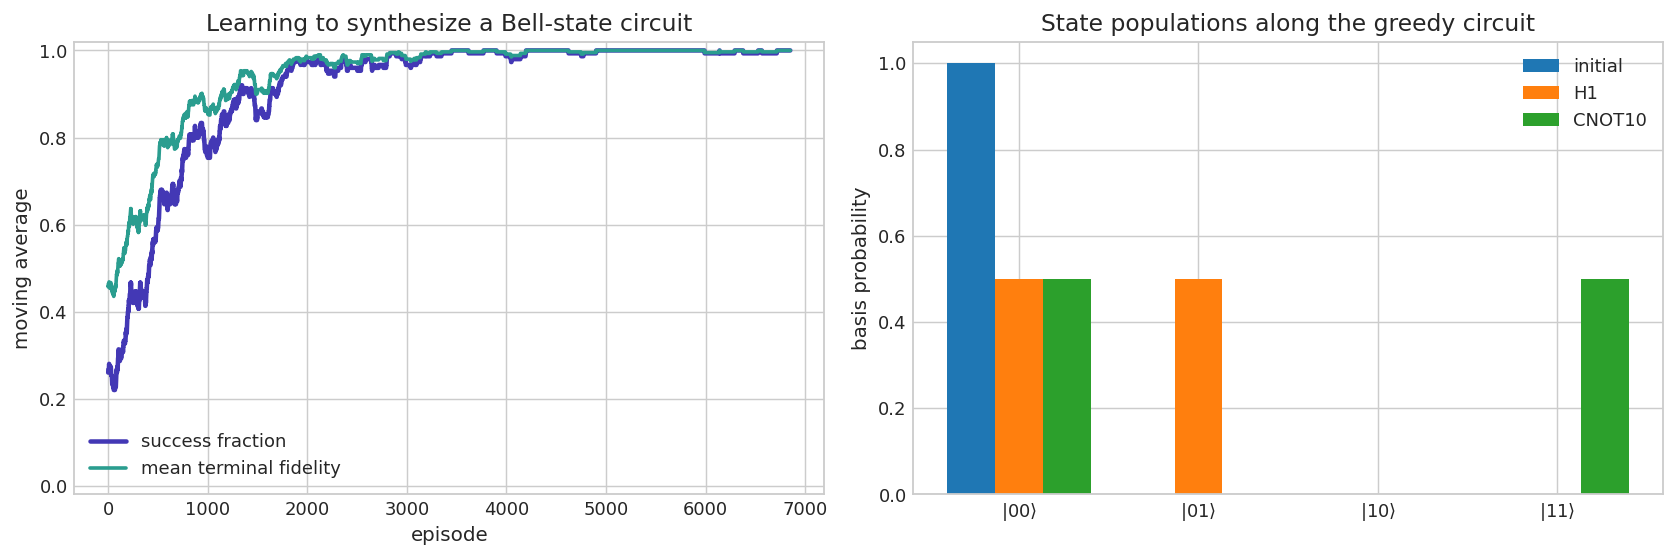

In [5]:
def moving_average(values, window=150):
    values = np.asarray(values)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(moving_average(circuit_success), color=UIO_PURPLE, lw=2.5,
             label="success fraction")
axes[0].plot(moving_average(circuit_fidelity), color=UIO_GREEN, lw=2,
             label="mean terminal fidelity")
axes[0].set(xlabel="episode", ylabel="moving average",
            ylim=(-0.02, 1.02), title="Learning to synthesize a Bell-state circuit")
axes[0].legend()

basis_labels = [r"$|00\rangle$", r"$|01\rangle$", r"$|10\rangle$", r"$|11\rangle$"]
width = 0.8 / len(circuit_states)
positions = np.arange(4)
for step, state in enumerate(circuit_states):
    probabilities = np.abs(state)**2
    label = "initial" if step == 0 else learned_sequence[step - 1]
    axes[1].bar(positions + (step - (len(circuit_states)-1)/2) * width,
                probabilities, width=width, label=label)
axes[1].set_xticks(positions, basis_labels)
axes[1].set(ylabel="basis probability", title="State populations along the greedy circuit")
axes[1].legend()
plt.tight_layout()
plt.show()

The target Bell state also depends on relative phase, so basis probabilities alone are not a sufficient validation. The fidelity calculation checks the complete statevector. In larger circuit-synthesis problems, rewards may combine target fidelity, depth, two-qubit gate count, hardware connectivity, and noise sensitivity. Sparse rewards and enormous combinatorial action spaces make credit assignment difficult.

## 4. Quantum feedback and measurement backaction

Feedback differs from open-loop control because measurement both reveals information and changes the state. A controller may require the complete measurement record

$$
h_t=(o_0,a_0,o_1,a_1,\ldots,o_t)
$$

or a filtered belief $b_t(\rho)$ derived from that record. Recurrent policies can approximate this filtering operation, but an explicit Bayesian filter is preferable when the model is tractable.

## Example 2: weak-measurement feedback for qubit stabilization

Consider a qubit subject to a bit-flip channel,

$$
\mathcal E(\rho)=(1-p)\rho+pX\rho X,
$$

and a weak $Z$ measurement with strength $\kappa$,

$$
M_0=\begin{pmatrix}\sqrt{(1+\kappa)/2}&0\\0&\sqrt{(1-\kappa)/2}\end{pmatrix},
\quad
M_1=\begin{pmatrix}\sqrt{(1-\kappa)/2}&0\\0&\sqrt{(1+\kappa)/2}\end{pmatrix}.
$$

The objective is to stabilize $|0\rangle$. We compare no feedback, a controller that reacts only to the latest outcome, and a Bayesian filter that retains the complete conditional density matrix.

In [6]:
def bit_flip_channel(rho, probability):
    return (1 - probability) * rho + probability * X @ rho @ X

def weak_measurement_operators(strength=0.42):
    M0 = np.diag([
        np.sqrt((1 + strength) / 2),
        np.sqrt((1 - strength) / 2),
    ]).astype(complex)
    M1 = np.diag([
        np.sqrt((1 - strength) / 2),
        np.sqrt((1 + strength) / 2),
    ]).astype(complex)
    return [M0, M1]

def measurement_update(rho, operators, outcome):
    unnormalized = operators[outcome] @ rho @ operators[outcome].conj().T
    probability = float(np.real(np.trace(unnormalized)))
    return unnormalized / probability, probability

def simulate_feedback(controller, steps=120, seed=0, flip_probability=0.035):
    local_rng = np.random.default_rng(seed)
    operators = weak_measurement_operators()
    physical_rho = pure_density(KET0)
    filter_rho = pure_density(KET0)
    fidelities, excited_beliefs, outcomes, actions = [], [], [], []

    for _ in range(steps):
        physical_rho = bit_flip_channel(physical_rho, flip_probability)
        filter_rho = bit_flip_channel(filter_rho, flip_probability)

        outcome_probabilities = []
        for operator in operators:
            outcome_probabilities.append(float(np.real(
                np.trace(operator @ physical_rho @ operator.conj().T)
            )))
        outcome = int(local_rng.choice([0, 1], p=outcome_probabilities))
        physical_rho, _ = measurement_update(physical_rho, operators, outcome)
        filter_rho, _ = measurement_update(filter_rho, operators, outcome)

        if controller == "none":
            action = 0
        elif controller == "latest outcome":
            action = int(outcome == 1)
        elif controller == "Bayesian filter":
            action = int(np.real(filter_rho[1, 1]) > 0.5)
        else:
            raise ValueError(controller)

        if action:
            physical_rho = apply_unitary_density(physical_rho, X)
            filter_rho = apply_unitary_density(filter_rho, X)

        fidelities.append(density_target_fidelity(physical_rho, KET0))
        excited_beliefs.append(float(np.real(filter_rho[1, 1])))
        outcomes.append(outcome)
        actions.append(action)

    return {
        "fidelity": np.asarray(fidelities),
        "excited_belief": np.asarray(excited_beliefs),
        "outcome": np.asarray(outcomes),
        "action": np.asarray(actions),
    }

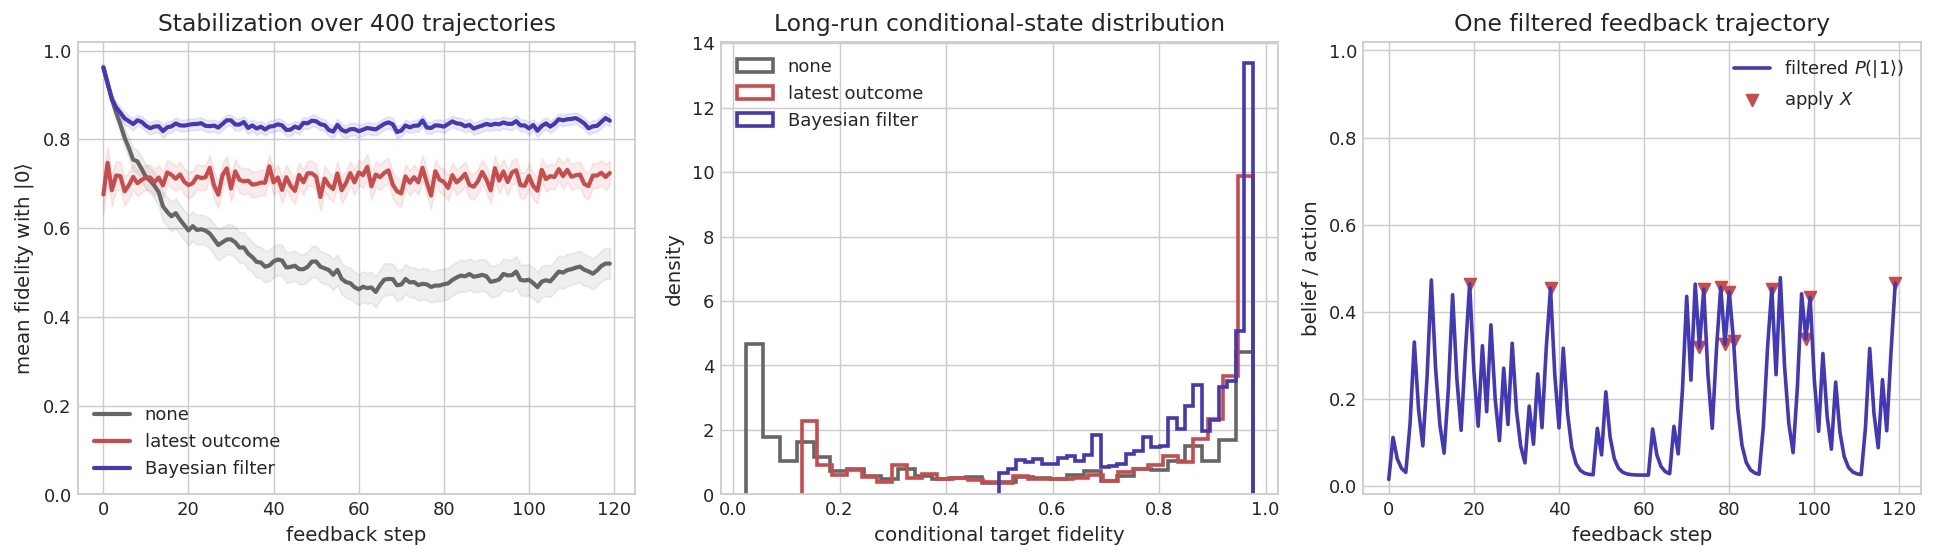

In [7]:
feedback_controllers = ["none", "latest outcome", "Bayesian filter"]
feedback_runs = {
    controller: [simulate_feedback(controller, seed=seed) for seed in range(400)]
    for controller in feedback_controllers
}
feedback_colors = {"none": "0.4", "latest outcome": UIO_RED,
                   "Bayesian filter": UIO_PURPLE}
sample_feedback = simulate_feedback("Bayesian filter", seed=19)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for controller in feedback_controllers:
    fidelity = np.stack([run["fidelity"] for run in feedback_runs[controller]])
    mean = fidelity.mean(axis=0)
    sem = fidelity.std(axis=0) / np.sqrt(len(fidelity))
    axes[0].plot(mean, lw=2.3, color=feedback_colors[controller], label=controller)
    axes[0].fill_between(np.arange(len(mean)), mean - 1.96 * sem,
                         mean + 1.96 * sem,
                         color=feedback_colors[controller], alpha=0.10)
axes[0].set(xlabel="feedback step", ylabel=r"mean fidelity with $|0\rangle$",
            ylim=(0, 1.02), title="Stabilization over 400 trajectories")
axes[0].legend()

for controller in feedback_controllers:
    long_run_fidelity = np.concatenate([
        run["fidelity"][40:] for run in feedback_runs[controller]
    ])
    axes[1].hist(long_run_fidelity, bins=30, density=True, histtype="step",
                 lw=2, color=feedback_colors[controller], label=controller)
axes[1].set(xlabel="conditional target fidelity", ylabel="density",
            title="Long-run conditional-state distribution")
axes[1].legend()

axes[2].plot(sample_feedback["excited_belief"], color=UIO_PURPLE, lw=2,
             label=r"filtered $P(|1\rangle)$")
action_times = np.flatnonzero(sample_feedback["action"])
axes[2].scatter(action_times, sample_feedback["excited_belief"][action_times],
                marker="v", color=UIO_RED, s=42, label="apply $X$")
axes[2].set(xlabel="feedback step", ylabel="belief / action",
            ylim=(-0.02, 1.02), title="One filtered feedback trajectory")
axes[2].legend()
plt.tight_layout()
plt.show()

This is a QND-inspired diagonal-state model, not a complete hardware model. It nevertheless displays the essential structure: the measurement record updates a conditional state, and feedback acts on that belief. The comparison should be made across trajectories because the conditional evolution is stochastic.

## 5. Quantum error correction as sequential inference and control

A decoder maps syndromes or syndrome histories to corrections. For a three-qubit bit-flip repetition code, the stabilizers are

$$
Z_1Z_2,\qquad Z_2Z_3.
$$

A single bit flip produces a distinct syndrome. A lookup decoder is sufficient here; RL becomes relevant for correlated noise, repeated measurements, adaptive actions, graph-structured codes, or joint decoding and control.

The evaluation target is the logical error rate, not the fraction of syndromes locally cleared. Logical failures can be rare, so statistical uncertainty and tail sampling matter.

physical error  $Z_1Z_2$  $Z_2Z_3$  decoder action
             I         1         1            none
            X1        -1         1 correct qubit 1
            X2        -1        -1 correct qubit 2
            X3         1        -1 correct qubit 3


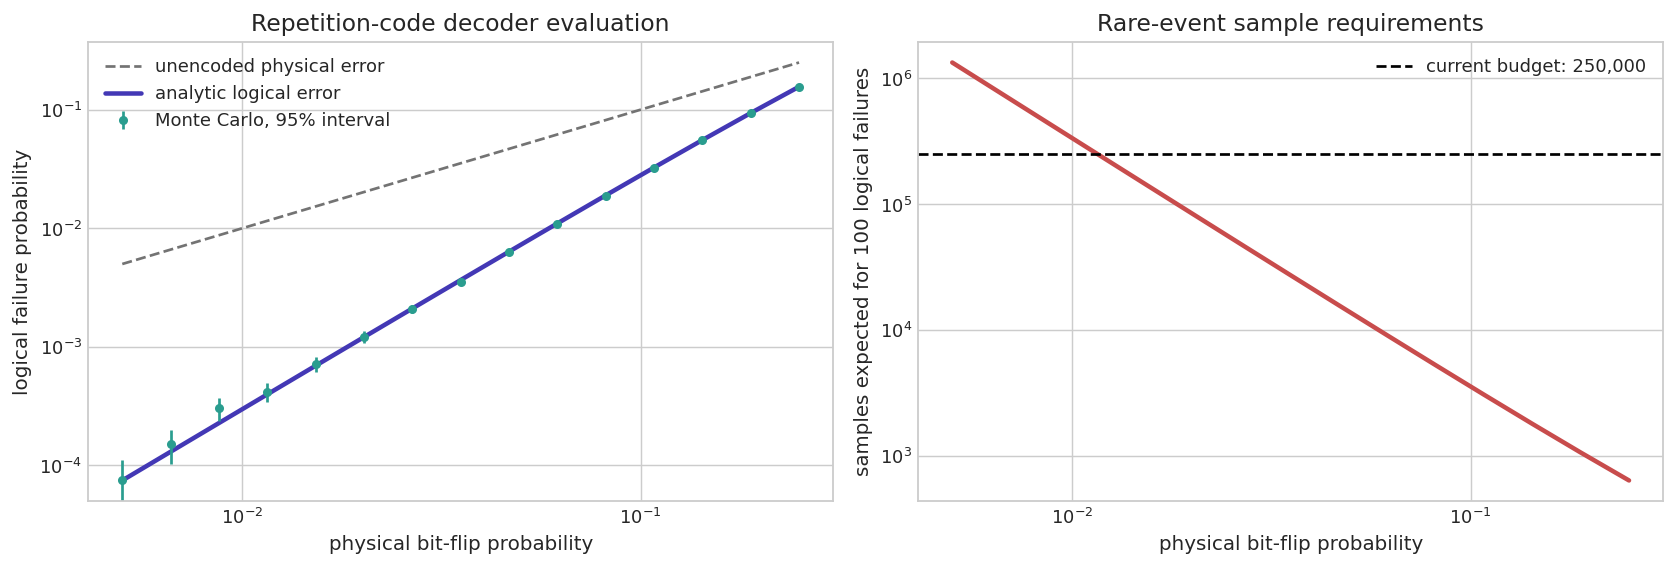

In [8]:
syndrome_table = pd.DataFrame({
    "physical error": ["I", "X1", "X2", "X3"],
    r"$Z_1Z_2$": [+1, -1, -1, +1],
    r"$Z_2Z_3$": [+1, +1, -1, -1],
    "decoder action": ["none", "correct qubit 1", "correct qubit 2", "correct qubit 3"],
})
print(syndrome_table.to_string(index=False))

qec_rng = np.random.default_rng(42)
physical_error_rates = np.geomspace(0.005, 0.25, 15)
shots = 250_000
estimated_logical = []
standard_errors = []
for probability in physical_error_rates:
    errors = qec_rng.random((shots, 3)) < probability
    logical_failures = errors.sum(axis=1) >= 2
    estimate = logical_failures.mean()
    estimated_logical.append(estimate)
    standard_errors.append(np.sqrt(max(estimate * (1 - estimate), 1 / shots**2) / shots))

estimated_logical = np.asarray(estimated_logical)
standard_errors = np.asarray(standard_errors)
analytic_logical = (
    3 * physical_error_rates**2 * (1 - physical_error_rates)
    + physical_error_rates**3
)
samples_for_100_failures = 100 / analytic_logical

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(physical_error_rates, physical_error_rates, "--", color="0.45",
               label="unencoded physical error")
axes[0].loglog(physical_error_rates, analytic_logical, color=UIO_PURPLE, lw=2.5,
               label="analytic logical error")
axes[0].errorbar(physical_error_rates, estimated_logical,
                 yerr=1.96 * standard_errors, fmt="o", ms=4,
                 color=UIO_GREEN, label="Monte Carlo, 95% interval")
axes[0].set(xlabel="physical bit-flip probability", ylabel="logical failure probability",
            title="Repetition-code decoder evaluation")
axes[0].legend()

axes[1].loglog(physical_error_rates, samples_for_100_failures,
               color=UIO_RED, lw=2.5)
axes[1].axhline(shots, ls="--", color="black", label=f"current budget: {shots:,}")
axes[1].set(xlabel="physical bit-flip probability",
            ylabel="samples expected for 100 logical failures",
            title="Rare-event sample requirements")
axes[1].legend()
plt.tight_layout()
plt.show()

For a learned decoder, the policy input must be specified precisely: current syndrome, a time window of syndrome changes, detector graph, leakage flags, or calibrated analog readout. Real-time latency, memory use, and scaling with code distance are part of performance. A decoder that is accurate but misses the hardware deadline is not operationally successful.

## 6. Adaptive quantum sensing

Quantum metrology is naturally sequential. An agent chooses an interrogation time, phase, basis, or sensor location; obtains a probabilistic measurement; updates its belief; and chooses the next experiment.

For a Ramsey-like binary measurement with analysis phase $\theta$ and visibility $v$,

$$
P(Y=0\mid\phi,\theta)=\frac12\left[1+v\cos(\phi-\theta)\right].
$$

The unknown phase $\phi$ is not directly observed. The posterior is the decision state. The following adaptive heuristic measures approximately at quadrature relative to the current circular posterior mean, where the likelihood is locally sensitive to phase.

In [9]:
phase_grid = np.linspace(-np.pi, np.pi, 721, endpoint=False)
phase_visibility = 0.92

def wrap_phase(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def circular_mean_from_posterior(posterior):
    resultant = np.sum(posterior * np.exp(1j * phase_grid))
    return 0.0 if abs(resultant) < 1e-12 else float(np.angle(resultant))

def posterior_entropy(posterior):
    safe = np.clip(posterior, 1e-15, None)
    return float(-np.sum(safe * np.log(safe)))

def run_phase_estimation(mode, true_phase=0.82, steps=32, seed=0):
    local_rng = np.random.default_rng(seed)
    posterior = np.ones_like(phase_grid) / len(phase_grid)
    entropies, errors, actions = [], [], []

    for _ in range(steps):
        if mode == "fixed":
            analysis_phase = 0.0
        elif mode == "adaptive":
            estimate = circular_mean_from_posterior(posterior)
            analysis_phase = wrap_phase(estimate + np.pi / 2)
        else:
            raise ValueError(mode)

        probability_zero_true = 0.5 * (
            1 + phase_visibility * np.cos(true_phase - analysis_phase)
        )
        outcome = int(local_rng.random() >= probability_zero_true)
        likelihood_zero = 0.5 * (
            1 + phase_visibility * np.cos(phase_grid - analysis_phase)
        )
        likelihood = likelihood_zero if outcome == 0 else 1 - likelihood_zero
        posterior = posterior * likelihood
        posterior = posterior / posterior.sum()

        estimate = circular_mean_from_posterior(posterior)
        entropies.append(posterior_entropy(posterior))
        errors.append(abs(wrap_phase(estimate - true_phase)))
        actions.append(analysis_phase)

    return {
        "posterior": posterior,
        "entropy": np.asarray(entropies),
        "error": np.asarray(errors),
        "action": np.asarray(actions),
    }

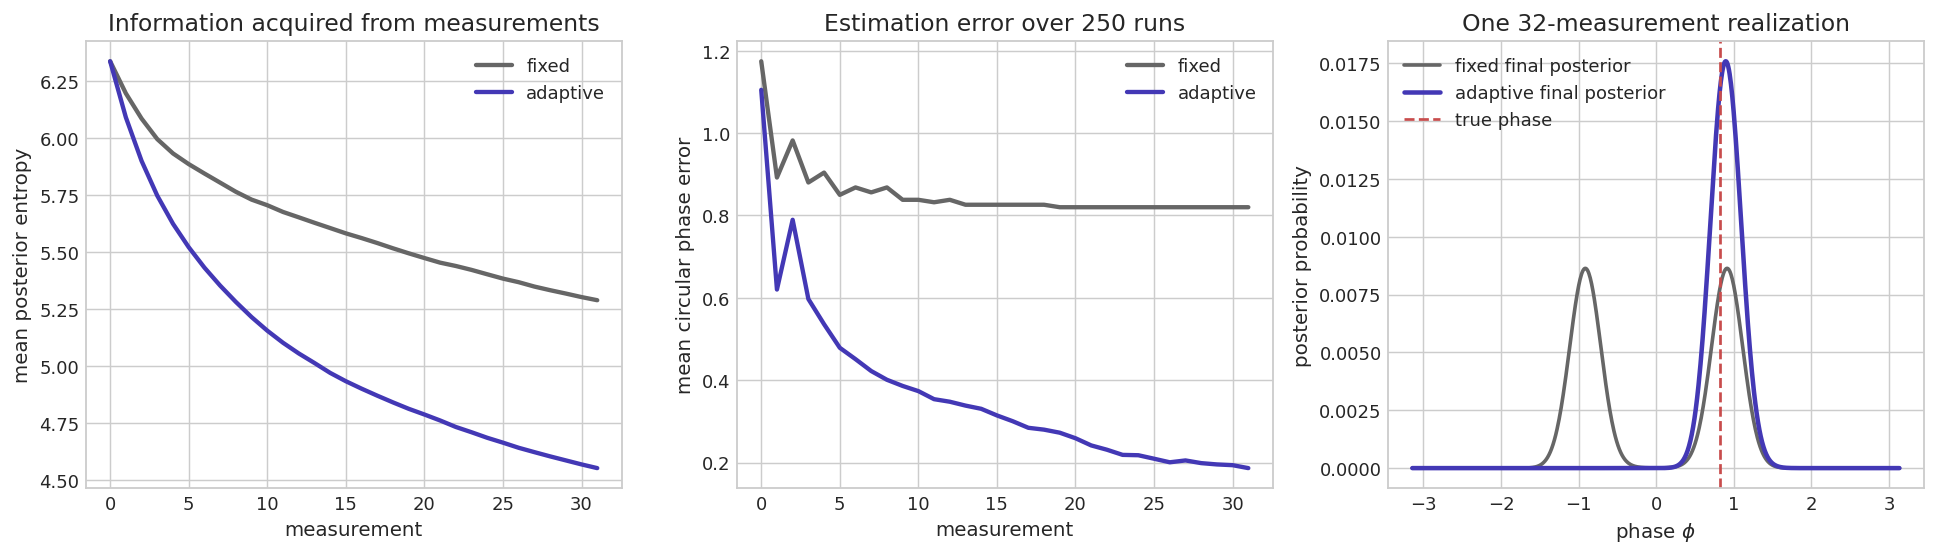

In [10]:
sensing_modes = ["fixed", "adaptive"]
sensing_runs = {
    mode: [run_phase_estimation(mode, seed=seed) for seed in range(250)]
    for mode in sensing_modes
}
sensing_colors = {"fixed": "0.4", "adaptive": UIO_PURPLE}
true_phase = 0.82
sample_adaptive = run_phase_estimation("adaptive", seed=17)
sample_fixed = run_phase_estimation("fixed", seed=17)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for mode in sensing_modes:
    entropy = np.stack([run["entropy"] for run in sensing_runs[mode]])
    error = np.stack([run["error"] for run in sensing_runs[mode]])
    axes[0].plot(entropy.mean(axis=0), color=sensing_colors[mode], lw=2.4,
                 label=mode)
    axes[1].plot(error.mean(axis=0), color=sensing_colors[mode], lw=2.4,
                 label=mode)
axes[0].set(xlabel="measurement", ylabel="mean posterior entropy",
            title="Information acquired from measurements")
axes[0].legend()
axes[1].set(xlabel="measurement", ylabel="mean circular phase error",
            title="Estimation error over 250 runs")
axes[1].legend()

axes[2].plot(phase_grid, sample_fixed["posterior"], color="0.4", lw=2,
             label="fixed final posterior")
axes[2].plot(phase_grid, sample_adaptive["posterior"], color=UIO_PURPLE, lw=2.5,
             label="adaptive final posterior")
axes[2].axvline(true_phase, ls="--", color=UIO_RED, label="true phase")
axes[2].set(xlabel=r"phase $\phi$", ylabel="posterior probability",
            title="One 32-measurement realization")
axes[2].legend()
plt.tight_layout()
plt.show()

The fixed measurement has a phase-reflection ambiguity because its likelihood depends on $\cos\phi$. Adaptive phase choices can break this symmetry. Reinforcement learning becomes useful when the action space includes multiple interrogation times, decoherence, hardware cost, non-Gaussian noise, or long-horizon experimental constraints that make exact Bayesian design difficult.

## 7. Classical RL on quantum systems versus quantum RL

These terms should not be conflated.

- **Classical RL on a quantum system:** a classical policy controls or diagnoses a quantum environment. All examples above belong to this category.
- **Quantum-enhanced RL:** a quantum subroutine is used for sampling, representation, search, or optimization inside an RL system.
- **Quantum policy or value model:** a parametrized quantum circuit represents $\pi_\theta$ or $Q_\theta$.
- **Coherent quantum agent-environment interaction:** actions, percepts, or rewards may remain in quantum registers.

A quantum implementation is not advantageous merely because it is quantum. Claims require an explicit computational task, resource accounting, noise model, and comparison to strong classical methods.

## Algorithm and validation checklist

| Problem structure | Plausible method | Essential validation |
|---|---|---|
| discrete pulse or gate set | Q-learning, DQN, tree search | exact solver and search baseline |
| bounded continuous controls | actor-critic, PPO, optimal control | GRAPE/CRAB and hardware constraints |
| measurement feedback | recurrent or belief-state policy | fresh trajectories and model mismatch |
| QEC decoding | graph/recurrent policy, supervised decoder | logical error rate and latency |
| adaptive sensing | Bayesian design, contextual or recurrent RL | posterior calibration and shot cost |

Before training, specify:

1. whether the policy observes a simulator state or a physical measurement;
2. the exact action timing, amplitude, connectivity, and bandwidth;
3. which quantities are available for reward during training and deployment;
4. the noise and drift distribution;
5. transparent physics and optimization baselines;
6. evaluation seeds, confidence intervals, and out-of-distribution tests.

## Problem set

1. Prove that the weak-measurement operators satisfy $M_0^\dagger M_0+M_1^\dagger M_1=I$.
2. Add a phase-flip channel to the feedback environment. Why can a $Z$-basis measurement not identify every coherent error?
3. Remove the identity action from circuit synthesis. How does this alter early termination, depth cost, and the learned policy?
4. Replace the Bell-state reward by basis-population agreement only. Construct a state that obtains the same populations but has zero Bell-state fidelity.
5. Derive the analytic logical failure probability of the three-qubit repetition code under independent bit flips.
6. Determine the number of Monte Carlo shots required for 10% relative standard error at $p=10^{-3}$. Why is rare-event sampling relevant?
7. Modify adaptive sensing to choose among several interrogation times with visibility $v(T)=e^{-T/T_2}$. Define a reward that balances information and duration.
8. Explain why a policy trained on exact statevectors may fail when deployed using finite-shot observables.

**Mini-project.** Build a recurrent or belief-state controller for qubit stabilization under simultaneous bit-flip noise, readout error, and parameter drift. Compare it with an explicit Bayesian filter and a controller based only on the latest measurement. Report target fidelity, action rate, calibration, and robustness to misspecified noise.

## Summary

Quantum RL is best understood as a family of sequential decision problems:

- state preparation and gate design optimize control protocols;
- circuit synthesis searches a structured program space;
- feedback policies act on measurement records or beliefs;
- QEC decoders infer and correct errors under latency constraints;
- adaptive metrology chooses measurements to reduce decision-relevant uncertainty.

Quantum dynamics do not remove the ordinary requirements of RL research. State and observation must be distinguished, rewards must be physically meaningful, constraints must be encoded, and evaluation must use external physics-based evidence.

**Further reading:** Lecture 8, *RL in Quantum Applications*; Bukov and Marquardt, [*Reinforcement Learning for Quantum Technology*](https://arxiv.org/abs/2601.18953); Wiseman and Milburn, *Quantum Measurement and Control*; standard references on quantum error correction and adaptive quantum metrology.